# Session 1: Python for R users  

JSM 2026 workshop material created by Ethan Meyers (Ethan.Meyers@gmail.com)


**Topics:**

1. Python basic syntax
2. Data structures: lists, tuples, dictionaries
3. Control flow: loops, conditionals & functions
4. NumPy arrays
5. Matplotlib basics



> **Note:** In Jupyter, only the *last* value in a code cell is displayed (unlike the R console, where every object on its own line prints). To show multiple items from one cell, call `print()` explicitly.

In [4]:
import sys

# Detect Google Colab and install any missing packages
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install pandas-datareader

---
## 1. Python Basic Syntax

Much of the syntax is similar between Python and R, so we won't dwell on small differences. Some basic Python syntax and R equivalents are below: 

| Operation | R | Python |
|--------|---|--------|
| Assignment | `a <- 7` | `a = 7` |
| Exponentiation | `2^3` → `8` | `2**3` → `8` |
| Booleans | `TRUE`, `FALSE` | `True`, `False` |
| Null value | `NULL` | `None` |
| Missing values | `NA` | *(no base-Python equivalent; NumPy/Pandas use `NaN`)* |
| Checking types | `class(a)` | `type(a)` |

> ⚠️ **Pitfall:** In Python, `^` is the **bitwise XOR** operator, not exponentiation.  
> `2^3` evaluates to `1` in Python, not `8`. Always use `**`.

In [1]:
# Assignment 



# We use ** for exponentiation rather than ^ which is a bitwise XOR



# Booleans: note the capitalization 



# Strings: As in R, single or double quotes (and """ for multi-line strings)



# Null values: None is equivalent to R's NULL




# We can check the type of value stored in a variable using the type() function




### 1.2 Strings

As in R, strings can use single or double quotes (plus triple quotes `"""..."""` for multi-line strings).

**f-strings** are Python's idiomatic way to embed values in strings. They work like `glue::glue()`, built into the language:

| Goal | R | Python |
|------|---|--------|
| Insert a value into a string | `paste("The value is", val)` | `f"The value is {val}"` |
| Same, with glue | `glue::glue("The value is {val}")` | `f"The value is {val}"` |
| Format a number | `sprintf("%.2f", x)` | `f"{x:.2f}"` |

**Methods are the biggest syntax shift from R.** In R, you call functions *on* data: `toupper(s)`, `nchar(s)`. In Python, most functionality lives in **methods** which are functions attached to the object itself. 

Methods are called with a dot. For example, if we have a string object called `s` we can create an upper case string using the method `s.upper()`. Typing `s.` and pressing `Tab` key in Jupyter shows you which methods belong to an object (along with other object properties).

Common string methods:

| Goal | R | Python |
|------|---|--------|
| Change case | `toupper(s)`,  `tolower(s)` | `s.upper()`,  `s.lower()` |
| Replace text | `gsub("a", "b", s)` | `s.replace("a", "b")` |
| Split on a delimiter | `strsplit(s, ",")` | `s.split(",")` |
| Trim whitespace | `trimws(s)` | `s.strip()` |
| Test for a prefix | `startsWith(s, "Py")` | `s.startswith("Py")` |
| Join strings with a separator | `paste(v, collapse=", ")` | `", ".join(my_list)` |
| String length | `nchar(s)` | `len(s)` *(a function, not a method)* |

In [3]:
# Create a basic string



# Build a string with an f-string





# A couple of string methods: .upper(), .replace(), .split()







### 1.3 Import Statements

In R, `library(pkg)` attaches *everything* in a package to your search path. Python is stricter: you `import` a module and access its contents through the module name, as if you always used `pkg::fun()` in R. One benefit is that you can always tell where a function came from when reading unfamiliar code.

The scientific Python stack has near-universal alias conventions. These four lines appear at the top of most data science scripts. Use them verbatim so your code matches the examples you find online:

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
```

In [4]:
# Three ways to import














# The closest thing to R's library() would be `from math import *`,
# but importing everything is bad form in Python: it hides where functions
# came from and silently overwrites existing ones.

> **What did the setup script do?** In R, `install.packages()` adds packages to one shared library. In Python we often install packages into a per-project **environment** (this is similar to using renv in R). The setup script used `uv` to read this project's package list from `pyproject.toml`, install everything into a hidden `.venv` folder, and launch JupyterLab from it. When Python "can't find" a package you know is installed, the usual cause is running in a different environment.

---
## 2. Data Structures

### 2.1 Lists

The Python `list` is the closest analog to an R vector, with a few critical differences:

1. **0-based indexing**: `my_list[0]` is the first element
2. **Not vectorized**: `my_list + 1` raises a `TypeError`
3. Lists can contain **mixed types** (e.g., strings, numbers, and Booleans, etc.)

| Operation | R | Python |
|-----------|---|--------|
| Create | `c(1, 2, 3)` | `[1, 2, 3]` |
| First element | `v[1]` | `my_list[0]` |
| Last element | `v[length(v)]` | `my_list[-1]` |
| Slice (2nd–4th) | `v[2:4]` *(includes 4)* | `my_list[1:4]` *(excludes 4)* |
| Length | `length(v)` | `len(my_list)` |
| Append | `c(v, x)` | `my_list.append(x)` |
| Mixed types | *(coerced: `c(1, "a")` → all character)* | allowed as-is: `[1, "a", True]` |

> ⚠️ **Pitfall:** A negative index means "count from the end": `my_list[-1]` is the **last** element.  
> In R, `v[-1]` means "drop the first element." Completely different!
>
> Slicing follows two rules that take some practice. First, the start is included and the stop is excluded: `my_list[1:4]` gives indices 1, 2, 3. Second, omitted endpoints default to the ends: `my_list[:3]` is the first three elements and `my_list[3:]` is everything from index 3 on. One consequence: a slice of length `k` always looks like `my_list[i:i+k]`. The same rules apply to NumPy arrays and Pandas `.iloc`.

In [ ]:
# Create a list of five numbers



# First element (0-based!)



# Last element (negative indexing)



# Slice: elements at indices 1, 2, 3 (index 4 excluded)



# Append in place with .append()



# len()



10
50
[20, 30, 40]
6


> ⚠️ **Pitfall: Lists are not vectorized**
>
> In R, `v + 1` adds 1 to every element. In Python, `my_list + 1` raises a `TypeError`.  
> Adding two lists *concatenates* them. You need NumPy for element-wise math.

In [9]:
# Demonstrate: list + number raises TypeError
numbers = [1, 2, 3]
# numbers + 1   # ← uncomment to see the error

# Adding two lists concatenates (does NOT add element-wise)
print(numbers + [4, 5, 6])

[1, 2, 3, 4, 5, 6]


> ⚠️ **Pitfall: Assignment is not a copy**
>
> R uses copy-on-modify semantics: modifying one variable doesn't affect another.  
> In Python, `b = a` gives two names for the **same** list object.

In [ ]:
# One needs to be careful when giving two variable names to the same list!
a = [1, 2, 3]








# Fix: use .copy()









a: [99, 2, 3]
a: [1, 2, 3]


> ⚠️ **Pitfall: Many list methods modify in place and return `None`**
>
> In R, functions return a new value and leave their input untouched: `sort(v)` returns a sorted copy. Python list methods like `.sort()`, `.append()`, and `.reverse()` modify the list **in place** and return `None`, so assigning the result discards your data.
>
> (Pandas behaves differently again: most DataFrame methods return a *new* object, which is what makes method chaining work. More in Session 2.)

In [ ]:
# Sorting in place









# If you want a sorted copy, use the sorted() function instead:






v: [1, 2, 3]
v2: None
v: [3, 1, 2]   v_sorted: [1, 2, 3]


### 2.2 Tuples

Tuples are **immutable** sequences: lists that cannot be modified after creation. R has no direct equivalent.

Main use cases: multiple return values from functions; dictionary keys. **Tuple unpacking** (`a, b = f(x)`) appears constantly in Python code. It is the pattern behind `fig, ax = plt.subplots()`, which you will see in every Matplotlib example.

In [ ]:
# Create a tuple
coords = (40.71, -74.01)   # New York City lat/lon



# Access elements (same indexing as lists)



# One can't reassign values to elements in a tuple




# Tuple unpacking: assigns multiple variables at once





40.71
40.71 -74.01


### 2.2b Dictionaries

Dictionaries allow you to access values based on a key. This is similar to R's named vectors and lists.

| Operation | R | Python |
|-----------|---|--------|
| Create | `my_list <- list(a=1, b=2)` | `d = {"a": 1, "b": 2}` |
| Access | `my_list$a` or `my_list[["a"]]` | `d["a"]` |
| Add/update | `my_list$c <- 3` | `d["c"] = 3` |
| Membership | `"a" %in% names(my_list)` | `"a" in d` |
| Safe access | returns `NULL` silently | `d.get("key", default)` avoids `KeyError` |

In [ ]:
# Create a dictionary



# Access a value by key



# Add a new key-value pair



# Check key membership with 'in'



# Safe access with .get(): returns None (or a default) instead of KeyError




Alice
{'name': 'Alice', 'age': 32, 'city': 'Boston'}
True
not found


---
## 3. Control Flow & Functions

### 3.1a For Loops

Python uses **colons and indentation** instead of braces. Indentation is not a style choice; it *is* the syntax.

```r
# R
for (x in my_vector) {
  cat(x, "\n")
}
```

```python
# Python
for x in my_list:
    print(x)   # indentation defines the loop body
```

A cultural difference worth knowing: loops are common and idiomatic in Python. Unlike R, where loops are often avoided in favor of vectorized code, Python loops are fast enough for everyday work. For numeric computation, though, NumPy vectorization (Section 4) is still the right tool.

#### Three Pythonic Loop Patterns to Know

| Goal | R idiom | Python equivalent |
|------|---------|------------------|
| Loop with index and value | `for (i in seq_along(v))` | `for i, x in enumerate(my_list):` |
| Loop over two sequences in parallel | `purrr::map2(v1, v2, f)` | `for a, b in zip(list1, list2):` |
| Transform each element | `purrr::map(v, f)` / `sapply(v, f)` | `[f(x) for x in my_list]` (list comprehension) |

In [5]:
fruits = ["apple", "banana", "cherry"]

# Basic for loop




# range(): produces integers 0..n-1, like seq(0, n-1)




# enumerate(): get index AND value together
# replaces: for (i in seq_along(fruits)) { ... }





# zip(): iterate two sequences in parallel




### 3.1b List Comprehensions

If one is creating a list using a loop, one can "list comprehension" offers a syntatic shortcut. The syntax is: 
`[expression for item in iterable if condition]`. 


In [6]:
# Square each number 1–10
# In R: sapply(1:10, function(x) x^2)





# Even numbers from 1–20 (with filter condition)
# In R: Filter(function(x) x %% 2 == 0, 1:20)




### 3.1c Conditionals

Python uses `elif` (not `else if`) and colons. Indentation defines blocks; there are no braces.

```r
# R
if (x > 0) "positive" else if (x < 0) "negative" else "zero"
```

```python
# Python
if x > 0:
    result = "positive"
elif x < 0:
    result = "negative"
else:
    result = "zero"
```

In [16]:
# Write a conditional to classify a number as "positive", "negative", or "zero"
x = -5

if x > 0:
    result = "positive"
elif x < 0:
    result = "negative"
else:
    result = "zero"

print(result)

negative


### 3.2 Functions

| Feature | R | Python |
|---------|---|--------|
| Define | `function(x, y=0) { ... }` | `def f(x, y=0):` |
| Return | Last expression (implicit) | Must use `return` explicitly |
| Multiple return | Returns last value (e.g., a list) | Returns a tuple; unpack with `a, b = f()` |
| No `return` | Returns `NULL` | Returns `None` |

In [8]:
# Define a function with a default argument; note the explicit return




# Call with and without the default




# Return multiple values as a tuple



    
# Unpack the multiple return values



> ⚠️ **Pitfall: Mutable Default Arguments**
>
> **Never use a list or dict as a default argument value.** The default object is created once, when the function is *defined*, not each time it is called, so it persists across calls.
>
> R doesn't have this issue because of copy-on-modify semantics.

In [18]:
# BAD: the default list is shared across all calls
def add_item_bad(item, my_list=[]):
    my_list.append(item)
    return my_list

print(add_item_bad("a"))  # ["a"]
print(add_item_bad("b"))  # ["a", "b"], not ["b"]!

# GOOD: use None; create the list inside the function
def add_item_good(item, my_list=None):
    if my_list is None:
        my_list = []
    my_list.append(item)
    return my_list

print(add_item_good("a"))  # ["a"]
print(add_item_good("b"))  # ["b"] ✓

['a']
['a', 'b']
['a']
['b']


---
## 4. NumPy

NumPy (Numerical Python) provides highly efficient, multi-dimensional arrays (ndarray), vectorized mathematical operations, and tools for linear algebra, Fourier transforms, and random numbers (it is very similar to some of the core functionality of MATLAB).

It allows for vectorized computations similar to R vectors (which are not supported by Python lists). 


```python
my_list = [1, 2, 3]
arr = np.array([1, 2, 3])

my_list * 2    # [1, 2, 3, 1, 2, 3]  ← repetition, not multiplication!
arr * 2        # array([2, 4, 6])     ← element-wise ✓
```

In [11]:
import numpy as np

### 4.1 Creating Arrays

| Goal | R | NumPy |
|------|---|-------|
| Array from values | `c(1, 2, 3)` | `np.array([1, 2, 3])` |
| Sequence with a step | `seq(0, 10, by=2)` | `np.arange(0, 11, 2)` |
| Evenly spaced sequence | `seq(0, 1, length.out=5)` | `np.linspace(0, 1, 5)` |
| Array of zeros | `rep(0, 5)` | `np.zeros(5)` |
| Array of ones | `rep(1, 5)` | `np.ones(5)` |

> Note: in `np.arange(0, 11, 2)`, the stop value `11` is **excluded**, like Python slicing.

In [9]:
# np.array() from a Python list



# np.arange(): like seq(start, stop, step), but the stop is EXCLUDED




# np.zeros() and np.ones()




### 4.2 Vectorized Operations

NumPy arrays support all the element-wise arithmetic R users expect from vectors.

Aggregations come in two equivalent forms: functions (`np.mean(arr)`) and **methods** (`arr.mean()`). 

> ⚠️ **Pitfall: there is no `na.rm=TRUE`.**
> If an array contains `np.nan`, then `arr.mean()` returns `nan`. Instead of an argument to remove NAs, NumPy has separate NaN-aware functions: `np.nanmean()`, `np.nansum()`, `np.nanmax()`, and so on. (Pandas makes the opposite choice and skips `NaN` by default).

In [12]:
arr = np.array([1, 2, 3, 4, 5])

# Element-wise arithmetic: +, -, *, /, **




# NumPy ufuncs (universal functions): np.sqrt, np.log, np.exp




# Aggregation as a method: arr.mean(), arr.std(), arr.sum()




# Missing values: compare .mean() vs np.nanmean()




### 4.3 Boolean Indexing

NumPy boolean indexing looks identical to R's logical subsetting:

| Goal | R | NumPy |
|------|---|-------|
| Filter by a condition | `v[v > 3]` | `arr[arr > 3]` |
| Combine conditions | `v[v > 1 & v < 4]` | `arr[(arr > 1) & (arr < 4)]` |
| Vectorized conditional | `ifelse(v > 3, "hi", "lo")` | `np.where(arr > 3, "hi", "lo")` |

> Use `&` and `|` for element-wise array operations (not `and` / `or`).

In [ ]:
arr = np.array([1, 4, 2, 7, 3, 9, 5])

# Filter: values greater than 4



# Combine conditions: values between 3 and 7
# Use & (not 'and') for element-wise operations



# Count values meeting a condition (True == 1)



# Vectorized conditional, like ifelse(arr > 4, "high", "low")



[7 9 5]
[4 5]
3
['low' 'low' 'low' 'high' 'low' 'high' 'high']


> ⚠️ **Pitfall: Slices are views, not copies**
>
> In R, subsetting always gives you a copy. A NumPy **slice** is a *view* into the same memory, so modifying the slice modifies the original array. Use `.copy()` when you want an independent copy. (Boolean indexing like `arr[arr > 4]` *does* return a copy.)
>
> This is the same "no implicit copies" behavior you saw with `b = a` for lists. It appears again in Pandas, where assigning through a chained selection never works; Session 2 shows the fix (a single `.loc` call).

In [23]:
arr = np.array([1, 2, 3, 4, 5])
sub = arr[:3]        # a view, not a copy
sub[0] = 99
print("arr:", arr)   # arr[0] changed too!

arr = np.array([1, 2, 3, 4, 5])
sub = arr[:3].copy()
sub[0] = 99
print("arr:", arr)   # unchanged ✓

arr: [99  2  3  4  5]
arr: [1 2 3 4 5]


### 4.3 Random Numbers

NumPy's random generation lives in a *generator* object: create it once with a seed, then call its methods. This replaces R's global `set.seed()`.

| Goal | R | NumPy |
|------|---|-------|
| Set a seed | `set.seed(42)` | `rng = np.random.default_rng(42)` |
| Normal draws | `rnorm(5)` | `rng.normal(0, 1, 5)` |
| Uniform draws | `runif(5)` | `rng.uniform(0, 1, 5)` |
| Sample without replacement | `sample(x, 3)` | `rng.choice(x, 3, replace=False)` |

(For the density, CDF, and quantile functions `dnorm`, `pnorm`, and `qnorm`, see `scipy.stats` in Session 2.)

In [13]:
# Create a generator with a seed, like set.seed(42)



# Normal draws, like rnorm(5)



# Uniform draws, like runif(5)



# Sample without replacement, like sample(1:10, 3)



# Reproducibility: the same seed gives the same draws



### 4.4 Higher dimensional Arrays *(if there is interest)*

| Goal | R | NumPy |
|------|---|-------|
| Create a matrix | `matrix(1:6, nrow=2, byrow=TRUE)` | `np.array([[1,2,3],[4,5,6]])` |
| Single element (row 1, col 2) | `m[1, 2]` | `m[0, 1]` *(0-based)* |
| First row | `m[1, ]` | `m[0, :]` |
| Second column | `m[, 2]` | `m[:, 1]` |
| Dimensions | `dim(m)` | `m.shape` |
| Column means | `colMeans(m)` | `m.mean(axis=0)` |
| Row means | `rowMeans(m)` | `m.mean(axis=1)` |

> **The `axis` argument is easy to get backwards.** `axis=0` collapses along the rows and produces one result per **column** (like `colMeans`). `axis=1` collapses along the columns and produces one result per **row**. A useful mnemonic: `axis` names the dimension that is **eliminated**. Pandas uses the same convention, so it is worth learning now.

(2, 3)
2
[1 2 3]
[2 5]
[2.5 3.5 4.5]
[2. 5.]


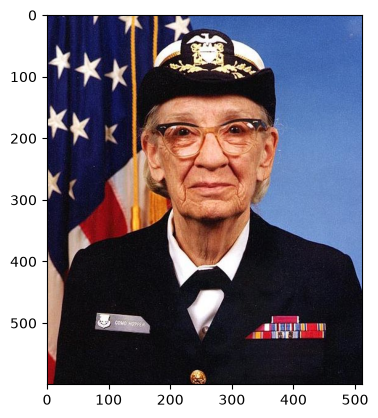

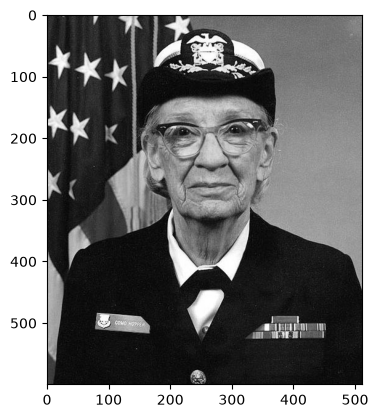

In [32]:
# Create a 2x3 array
m = np.array([[1, 2, 3],
              [4, 5, 6]])

# Check shape
print(m.shape)         # (2, 3)

# Access element at row 0, column 1
print(m[0, 1])         # 2

# Slice: entire first row
print(m[0, :])         # [1 2 3]

# Slice: entire second column
print(m[:, 1])         # [2 5]

# Column means with .mean(axis=0), row means with .mean(axis=1)
print(m.mean(axis=0))  # [2.5 3.5 4.5], like colMeans(m)
print(m.mean(axis=1))  # [2. 5.], like rowMeans(m)



# View an image
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from imageio.v3 import imread

# Load the image into a NumPy array
hopper = imread(cbook.get_sample_data("grace_hopper.jpg"))

plt.imshow(hopper);
plt.show()

plt.imshow(np.mean(hopper, axis = 2), cmap = "gray");


---
## 5. Matplotlib

Matplotlib's **object-oriented interface** creates a `Figure` (canvas) with one or more `Axes` (subplots), then adds data by calling methods on the axes.

> **R comparison:** This is like base R graphics in the sense that it operates on sequences (lists, arrays, etc) similar to the way that base R operates on vectors.
> Seaborn figure-level plots (Session 2) are closer to ggplot2 since they operates on DataFrames.

```python
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("My Plot")
plt.show()
```

The cell below load data on Egg prices into two lists: 
- `egg_prices`: the average price of a dozen eggs measured each month
- `egg_dates`: the date when the price was recorded

You can ignore the code that loads this data and just use these lists in the examples below. 

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas_datareader import data as pdr

# Fetch the monthly egg price series from FRED
try:
    egg_df = pdr.DataReader("APU0000708111", "fred", start="2000-01-01")
    egg_df = (egg_df
              .rename(columns={"APU0000708111": "price_per_dozen"})
              .reset_index()
              .rename(columns={"DATE": "date"})
              .dropna())
except Exception:
    # No internet? Load the cached copy instead.
    egg_df = pd.read_csv("data/egg_prices.csv", parse_dates=["date"])

# Pandas comes in Session 2; for today, plain Python lists are all we need
egg_dates = egg_df["date"].to_list()
egg_prices = egg_df["price_per_dozen"].to_list()

print(egg_dates[:3])
print(egg_prices[:3])

[Timestamp('2000-01-01 00:00:00'), Timestamp('2000-02-01 00:00:00'), Timestamp('2000-03-01 00:00:00')]
[0.975, 0.962, 0.931]


In [14]:
# Line plot: egg price over time (two lists: x values and y values)








In [15]:
# Create two subplots




# Bar chart: wealth distribution
categories = ["Bottom 50%", "Next 40%", "Top 9%", "Top 1%"]
wealth_share = [2.5, 26.5, 37.0, 34.0]








# Histogram of egg prices (one list of values)








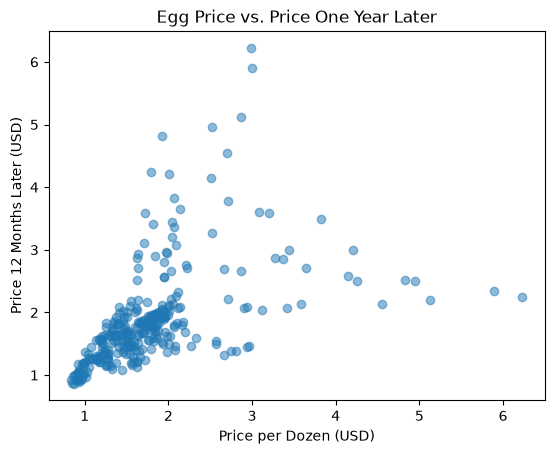

In [5]:
# Scatter plot
# Each point: a month's price vs. the price 12 months later
# List slicing from Section 2 does the alignment

fig, ax = plt.subplots()
ax.scatter(egg_prices[:-12], egg_prices[12:], alpha=0.5)
ax.set_xlabel("Price per Dozen (USD)")
ax.set_ylabel("Price 12 Months Later (USD)")
ax.set_title("Egg Price vs. Price One Year Later")
plt.show()